# Certified Kernels

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/piyush314/neumanOpt/blob/main/docs/tutorials/02_certified_kernels.ipynb)

Open this notebook in Colab if you want to inspect the shipped certificates from the browser before setting up a local environment.

This notebook explains how to read the shipped radix-15 and radix-24 certificates before you inspect any fields programmatically.

In this repository, a certificate is a machine-readable record for one specific higher-radix kernel. It includes:

- the kernel identifier and radix,
- the number of kernel products used in the construction,
- a local interval description of the error map,
- and a small set of safe radii summarizing where the kernel is certified to behave well.

This notebook focuses on how to inspect the certificates and understand which fields matter first.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_repo_root(start=None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


ROOT = find_repo_root()
sys.path.insert(0, str(ROOT / "src"))


In [2]:
from neumann_kernels import load_certified_kernel

rad15 = load_certified_kernel("radix15", root=ROOT)
rad24 = load_certified_kernel("radix24", root=ROOT)
summary = [rad15, rad24]
[(item["kernel_id"], item["safe_radii"], item["product_count"]) for item in summary]


[('radix15',
  {'eta_certified': 0.9708979592132976,
   'q_certified': 0.970699488396904,
   'q_estimated': 0.9708979592133136},
  4),
 ('radix24',
  {'eta_certified': 0.9745597378208228,
   'q_certified': 0.9841760858923094,
   'q_estimated': 0.9844321098682287},
  5)]

The first fields to read are the safe radii.

- `eta_certified` is the certified radius for the simpler coefficient-based majorant.
- `q_certified` is the sharper certified contraction-style radius.
- `q_estimated` is the numerical estimate that motivated certification, but it is not itself the certified guarantee.

The next plot is therefore a high-level summary: before looking at interval data, ask which certified radius each kernel can support.

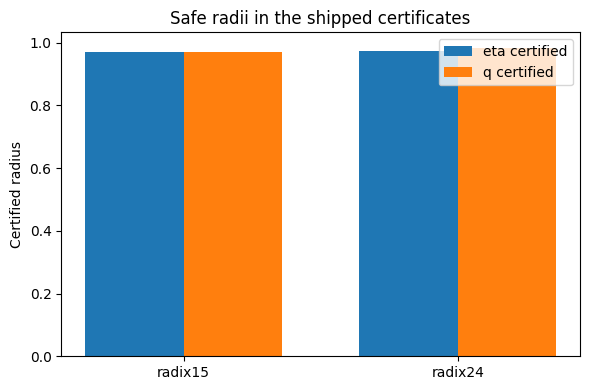

In [3]:
labels = [item["kernel_id"] for item in summary]
eta = [item["safe_radii"]["eta_certified"] for item in summary]
q = [item["safe_radii"]["q_certified"] for item in summary]

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(labels))
ax.bar([i - 0.18 for i in x], eta, width=0.36, label="eta certified")
ax.bar([i + 0.18 for i in x], q, width=0.36, label="q certified")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel("Certified radius")
ax.set_title("Safe radii in the shipped certificates")
ax.legend()
plt.tight_layout()


After the high-level radii, the next useful questions are local and qualitative:

- how was this certificate sourced,
- what note explains the construction or refinement path,
- and what does one representative interval record look like?

That is what the final inspection cell shows.

In [4]:
for item in summary:
    print(f"=== {item['kernel_id']} ===")
    print("status:", item["source_label"])
    print("note  :", item["source_note"])
    print("safe radii:", item["safe_radii"])
    print("first interval:", item["error_map_intervals"][0])
    print()


=== radix15 ===
status: appendix-radix15
note  : High-precision appendix circuit; prefix error is already at double precision.
safe radii: {'eta_certified': 0.9708979592132976, 'q_certified': 0.970699488396904, 'q_estimated': 0.9708979592133136}
first interval: {'degree': 15, 'midpoint': 0.8147910024806893, 'radius': 2.0424582403280887e-13, 'lo': 0.814791002480485, 'hi': 0.8147910024808935, 'abs_upper': 0.8147910024808935}

=== radix24 ===
status: appendix-radix24-refined
note  : Started from the appendix decimal circuit and refined locally with SciPy (Powell plus Nelder-Mead) to restore prefix exactness.
safe radii: {'eta_certified': 0.9745597378208228, 'q_certified': 0.9841760858923094, 'q_estimated': 0.9844321098682287}
first interval: {'degree': 24, 'midpoint': 0.35517020765347895, 'radius': 3.620466625387758e-09, 'lo': 0.3551702040330123, 'hi': 0.3551702112739456, 'abs_upper': 0.3551702112739456}



At this point you should know how to read the top-level certificate structure: summary radii first, provenance second, interval details last. The next notebook steps back and explains the simpler cost model that motivates why higher-radix kernels are attractive in the first place.